개인CB  : (3129036, 71)  |  bad rate: 0.51%
통신CB  : (2640000, 6)

[Table A] Dataset Overview
                  Dataset                     Source        Period             N   Features   Bad rate                Split
  Individual CB (File 09)   AI Hub (dataSetSn=71792) 2021Q4–2022Q4     3,129,036         64      0.51% Train 70% / Test 30%
Telecom-Card-CB (File 11)   AI Hub (dataSetSn=71792) 2021Q1–2022Q4     2,640,000          4 N/A (no Y)  JSD refinement only
Statista Macro Indicators Statista Consumer Insights     2020–2022 34 indicators 2 (KR, ID)        N/A     CosSim component

[Table B] Variable Group Summary — Individual CB
          Group  N variables  Mean (mean)  Std (mean)  Missing% (mean)  IV mean  IV max
       Card (C)           29    6514.0932  44052.1458            12.65   1.1328  3.0791
       Loan (L)           22    2436.8534   5260.1944             0.00   0.5987  1.1320
Asset index (U)            9  169224.0622 933482.7562             0.00   0.1869  0.2882
Alternative

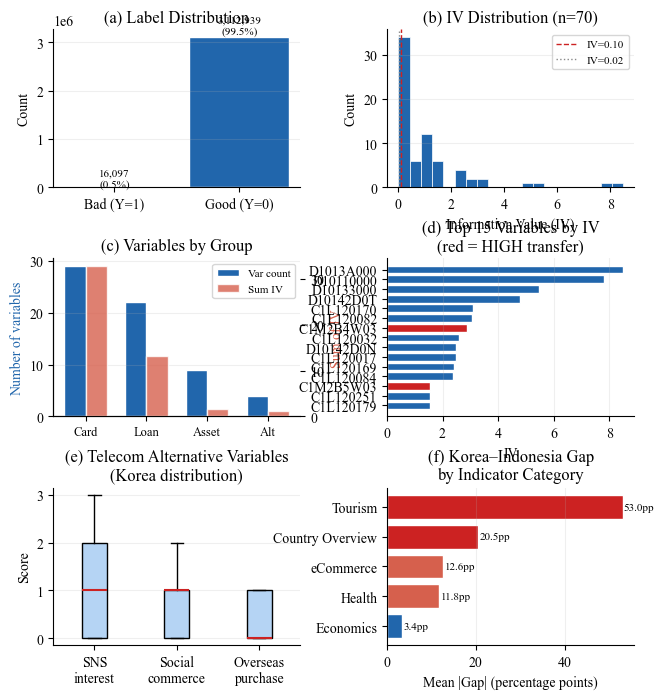


  Section 4.2 기재용 핵심 수치

  [개인CB 데이터]
  총 샘플              : 3,129,036건
  Train / Test         : 2,190,325 / 938,711
  Bad rate             : 0.51%
  최종 모형 변수       : 64개
    Card               : 29개  (IV sum=32.85)
    Loan               : 22개  (IV sum=13.17)
    Asset              : 9개  (IV sum=1.68)
    Alternative        : 4개  (IV sum=1.16)

  [통신CB 데이터]
  총 샘플              : 2,640,000건 (8개 분기)
  대안변수             : 4개 (SNS·eComm·SocialComm·OverseasPurchase)
  결측률               : 0% (전 변수)

  [Statista 거시지표]
  CosSim 입력 지표     : 34개 (percent 단위)
  평균 한-인니 갭      : 14.0pp
  최대 갭 지표         : Share intending to travel abroad (53.0pp)

저장 완료:
  outputs/tables/TableA_dataset_overview.csv
  outputs/tables/TableB_group_stats.csv
  outputs/tables/TableC_key_vars_stats.csv
  outputs/tables/TableD_telecom_stats.csv
  outputs/tables/TableE_macro_comparison.csv
  outputs/figures/Fig6_descriptive.pdf/png

→ 논문 초안 작성 단계로 진행


In [1]:
# ============================================================
# 04c_descriptive_statistics
# 논문 Section 4.2 Data Description 용 기술통계 생성
# 대상: 개인CB (64개 변수) + 통신카드CB (4개 대안변수)
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman', 'DejaVu Serif'],
    'font.size'        : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# %% [2] 데이터 로드
train = pd.read_csv('data/aihub_raw/02_train_final.csv', low_memory=False)
test  = pd.read_csv('data/aihub_raw/02_test_final.csv',  low_memory=False)
df_cb = pd.concat([train, test], ignore_index=True)

final_vars  = pd.read_csv('outputs/tables/03_final_vars.csv')['variable'].tolist()
iv_df       = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
transfer_df = pd.read_csv('outputs/tables/05_transfer_variables.csv')

# 통신CB 로드
files = sorted(glob.glob('data/aihub_raw/*통신카드CB결합*.csv'))
TELECOM_COLS = ['BASE_YM','CUST_ID',
                'R3M_ITRT_COMM_SNS', 'CD_USE_AMT',
                'R3M_ITRT_SHOP_SOCIAL', 'R3M_ITRT_SHOP_JIKGU']
dfs_tel = [pd.read_csv(f, encoding='cp949',
                        usecols=TELECOM_COLS, low_memory=False)
           for f in files]
df_tel = pd.concat(dfs_tel, ignore_index=True)

print(f"개인CB  : {df_cb.shape}  |  bad rate: {df_cb['Y'].mean()*100:.2f}%")
print(f"통신CB  : {df_tel.shape}")

# %% [3] ── Table A: 전체 데이터셋 개요 ─────────────────────────
print("\n[Table A] Dataset Overview")

overview = pd.DataFrame([
    {'Dataset'    : 'Individual CB (File 09)',
     'Source'     : 'AI Hub (dataSetSn=71792)',
     'Period'     : '2021Q4–2022Q4',
     'N'          : f"{len(df_cb):,}",
     'Features'   : len(final_vars),
     'Bad rate'   : f"{df_cb['Y'].mean()*100:.2f}%",
     'Split'      : 'Train 70% / Test 30%'},
    {'Dataset'    : 'Telecom-Card-CB (File 11)',
     'Source'     : 'AI Hub (dataSetSn=71792)',
     'Period'     : '2021Q1–2022Q4',
     'N'          : f"{len(df_tel):,}",
     'Features'   : 4,
     'Bad rate'   : 'N/A (no Y)',
     'Split'      : 'JSD refinement only'},
    {'Dataset'    : 'Statista Macro Indicators',
     'Source'     : 'Statista Consumer Insights',
     'Period'     : '2020–2022',
     'N'          : '34 indicators',
     'Features'   : '2 (KR, ID)',
     'Bad rate'   : 'N/A',
     'Split'      : 'CosSim component'},
])
print(overview.to_string(index=False))
overview.to_csv('outputs/tables/TableA_dataset_overview.csv',
                index=False, encoding='utf-8-sig')

# %% [4] ── Table B: 개인CB 변수 그룹별 기술통계 ────────────────
print("\n[Table B] Variable Group Summary — Individual CB")

def group_stats(df, vars_list, group_name):
    sub = df[vars_list].copy()
    return {
        'Group'         : group_name,
        'N variables'   : len(vars_list),
        'Mean (mean)'   : round(sub.mean().mean(), 4),
        'Std (mean)'    : round(sub.std().mean(),  4),
        'Missing% (mean)': round(sub.isnull().mean().mean()*100, 2),
        'IV mean'       : round(iv_df[iv_df['variable'].isin(vars_list)]['iv'].mean(), 4),
        'IV max'        : round(iv_df[iv_df['variable'].isin(vars_list)]['iv'].max(),  4),
    }

groups = {
    'Card (C)'       : [v for v in final_vars if v.startswith('C')],
    'Loan (L)'       : [v for v in final_vars if v.startswith('L')],
    'Asset index (U)': [v for v in final_vars if v.startswith('U')],
    'Alternative (A)': [v for v in final_vars if v.startswith('A')],
}

table_b_rows = [group_stats(df_cb, cols, nm)
                for nm, cols in groups.items()]
table_b = pd.DataFrame(table_b_rows)
print(table_b.to_string(index=False))
table_b.to_csv('outputs/tables/TableB_group_stats.csv',
               index=False, encoding='utf-8-sig')

# %% [5] ── Table C: 핵심 변수 상세 기술통계 (논문 본문용) ────────
print("\n[Table C] Descriptive Statistics — Key Variables")

# HIGH 이전 가능성 변수 + 상위 IV 변수 포함
key_vars = transfer_df[transfer_df['transfer']=='HIGH']['variable'].tolist()
# IV 상위 5개 추가 (이미 포함된 것 제외)
top_iv = iv_df.sort_values('iv', ascending=False).head(10)
for v in top_iv['variable']:
    if v not in key_vars and len(key_vars) < 15:
        key_vars.append(v)

# 변수 설명 매핑
VAR_DESC = {
    'C1M2B4W03' : 'Credit card lump-sum usage amount (3M)',
    'C1M2B5W03' : 'Credit card installment usage amount (3M)',
    'C1Z001373' : 'Total card usage amount (3M, active)',
    'C1M210000' : 'Number of credit cards (active)',
    'C1L120082' : 'Credit cards with valid CA limit (active)',
    'C1L120032' : 'Credit cards with valid limit (active)',
    'C1L120170' : 'CA limit issuer count (active)',
    'C1L120017' : 'Issuer count with valid limit (active)',
    'U81201010' : 'Asset evaluation index (total asset value)',
    'U81202010' : 'Asset evaluation index (net asset value)',
    'U81203010' : 'Asset evaluation index (total, binned)',
    'U81204010' : 'Asset evaluation index (net, binned)',
    'AL012G019' : '3-year mobile phone number history count',
    'AL012G005' : '3-year address history count',
    'AL012G011' : '3-year workplace history count',
    'AS120G001' : 'Current residence size (binned)',
    'L10210000' : 'Number of loans (active)',
    'L10231000' : 'Total committed loan amount (active)',
    'L10216000' : 'Number of unsecured loans (active)',
    'L10220000' : 'Number of loan institutions (active)',
}

table_c_rows = []
for var in key_vars:
    if var not in df_cb.columns:
        continue
    s    = df_cb[var].dropna()
    iv_v = iv_df[iv_df['variable']==var]['iv'].values
    iv_v = iv_v[0] if len(iv_v) > 0 else np.nan
    tr   = transfer_df[transfer_df['variable']==var]['transfer'].values
    tr   = tr[0] if len(tr) > 0 else '—'
    grp  = ('Card' if var.startswith('C') else
            'Loan' if var.startswith('L') else
            'Asset' if var.startswith('U') else 'Alternative')
    table_c_rows.append({
        'Variable'    : var,
        'Group'       : grp,
        'Description' : VAR_DESC.get(var, ''),
        'N'           : len(s),
        'Mean'        : round(s.mean(),   4),
        'Std'         : round(s.std(),    4),
        'Min'         : round(s.min(),    4),
        'P25'         : round(s.quantile(0.25), 4),
        'Median'      : round(s.median(), 4),
        'P75'         : round(s.quantile(0.75), 4),
        'Max'         : round(s.max(),    4),
        'Missing%'    : round(df_cb[var].isnull().mean()*100, 2),
        'IV'          : round(iv_v, 4),
        'Transfer'    : tr,
    })

table_c = pd.DataFrame(table_c_rows)
print(table_c[['Variable','Group','Mean','Std',
               'Median','Missing%','IV','Transfer']].to_string(index=False))
table_c.to_csv('outputs/tables/TableC_key_vars_stats.csv',
               index=False, encoding='utf-8-sig')

# %% [6] ── Table D: 통신CB 대안변수 기술통계 ─────────────────
print("\n[Table D] Descriptive Statistics — Telecom Alternative Variables")

TELECOM_MAP = {
    'R3M_ITRT_COMM_SNS'    : ('comm_sns_22_1',    'SNS community interest score (3M)',    70.0),
    'CD_USE_AMT'           : ('shc_236_222Q',     'Card usage amount (e-Commerce proxy)', 57.0),
    'R3M_ITRT_SHOP_SOCIAL' : ('shop_social_22_2', 'Social commerce interest score (3M)',  57.0),
    'R3M_ITRT_SHOP_JIKGU'  : ('shop_jikgu_22_2',  'Overseas direct purchase interest (3M)',19.0),
}

table_d_rows = []
for col, (report_nm, desc, id_val) in TELECOM_MAP.items():
    if col not in df_tel.columns:
        continue
    s = df_tel[col].dropna()
    table_d_rows.append({
        'Variable (report)' : report_nm,
        'Column (AI Hub)'   : col,
        'Description'       : desc,
        'N'                 : f"{len(s):,}",
        'Mean'              : round(s.mean(),        3),
        'Std'               : round(s.std(),         3),
        'Min'               : round(s.min(),         3),
        'Median'            : round(s.median(),      3),
        'Max'               : round(s.max(),         3),
        'Missing%'          : round(df_tel[col].isnull().mean()*100, 1),
        'ID proxy (%)'      : id_val,
        'Quarters'          : 8,
    })

table_d = pd.DataFrame(table_d_rows)
print(table_d[['Variable (report)','Column (AI Hub)',
               'Mean','Std','Median','Missing%',
               'ID proxy (%)']].to_string(index=False))
table_d.to_csv('outputs/tables/TableD_telecom_stats.csv',
               index=False, encoding='utf-8-sig')

# %% [7] ── Table E: 인도네시아-한국 비교 (CosSim 입력) ─────────
print("\n[Table E] Korea–Indonesia Macro Indicator Comparison")

statista = pd.read_csv('data/indonesia_korea_statistics.csv')
statista['indonesia_value'] = pd.to_numeric(
    statista['indonesia_value'], errors='coerce')
statista['korea_value'] = pd.to_numeric(
    statista['korea_value'], errors='coerce')

mask = (statista['unit'].str.lower().str.contains('percent', na=False) &
        statista['indonesia_value'].notna() &
        statista['korea_value'].notna())
cos_df = statista[mask].copy()
cos_df['gap'] = (cos_df['korea_value'] - cos_df['indonesia_value']).round(2)
cos_df['gap_abs'] = cos_df['gap'].abs()

table_e = cos_df[['category','indicator','indonesia_value',
                   'korea_value','gap','unit']].copy()
table_e.columns = ['Category','Indicator','Indonesia (%)','Korea (%)','Gap','Unit']
table_e = table_e.sort_values(['Category','Gap'])

print(f"  총 지표 수 : {len(table_e)}개")
print(f"\n  [카테고리별 평균 Gap]")
print(cos_df.groupby('category').agg(
    n=('indicator','count'),
    mean_id=('indonesia_value','mean'),
    mean_kr=('korea_value','mean'),
    mean_gap=('gap_abs','mean')
).round(2).to_string())
table_e.to_csv('outputs/tables/TableE_macro_comparison.csv',
               index=False, encoding='utf-8-sig')

# %% [8] ── Figure 6: 데이터 기술통계 시각화 ─────────────────
fig = plt.figure(figsize=(7.5, 8))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# (a) Y변수 분포
ax1 = fig.add_subplot(gs[0, 0])
counts = [df_cb['Y'].sum(), (df_cb['Y']==0).sum()]
bars = ax1.bar(['Bad (Y=1)', 'Good (Y=0)'], counts,
               color=['#CC2222','#2166ac'], edgecolor='white')
ax1.set_ylabel('Count')
ax1.set_title('(a) Label Distribution')
ax1.grid(axis='y', alpha=0.2)
for b, v in zip(bars, counts):
    ax1.text(b.get_x()+b.get_width()/2, v*1.02,
             f'{v:,}\n({v/sum(counts)*100:.1f}%)',
             ha='center', fontsize=8)

# (b) IV 분포 히스토그램
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(iv_df['iv'], bins=20, color='#2166ac',
         edgecolor='white', linewidth=0.5)
ax2.axvline(x=0.1,  color='#CC2222',  linestyle='--', lw=1, label='IV=0.10')
ax2.axvline(x=0.02, color='#888888',  linestyle=':',  lw=1, label='IV=0.02')
ax2.set_xlabel('Information Value (IV)')
ax2.set_ylabel('Count')
ax2.set_title('(b) IV Distribution (n=70)')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.2)

# (c) 그룹별 변수 수 & IV 합계
ax3 = fig.add_subplot(gs[1, 0])
grp_names = list(groups.keys())
grp_cnts  = [len(v) for v in groups.values()]
grp_ivsum = [iv_df[iv_df['variable'].isin(v)]['iv'].sum()
             for v in groups.values()]
x = np.arange(len(grp_names))
w = 0.35
ax3b = ax3.twinx()
ax3.bar(x-w/2, grp_cnts,  width=w, color='#2166ac',
        label='Var count', edgecolor='white')
ax3b.bar(x+w/2, grp_ivsum, width=w, color='#d6604d',
         label='Sum IV', edgecolor='white', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(['Card','Loan','Asset','Alt'], fontsize=9)
ax3.set_ylabel('Number of variables', color='#2166ac')
ax3b.set_ylabel('Sum of IV',          color='#d6604d')
ax3.set_title('(c) Variables by Group')
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, fontsize=8)
ax3.grid(axis='y', alpha=0.2)

# (d) 핵심 변수 IV 순위 (Top 15)
ax4 = fig.add_subplot(gs[1, 1])
top15 = iv_df.sort_values('iv', ascending=False).head(15)
colors_bar = ['#CC2222' if v in transfer_df[
    transfer_df['transfer']=='HIGH']['variable'].values
    else '#2166ac' for v in top15['variable']]
ax4.barh(top15['variable'][::-1], top15['iv'][::-1],
         color=colors_bar[::-1], edgecolor='white')
ax4.set_xlabel('IV')
ax4.set_title('(d) Top 15 Variables by IV\n(red = HIGH transfer)')
ax4.grid(axis='x', alpha=0.2)

# (e) 통신CB 대안변수 분포 (박스플롯)
ax5 = fig.add_subplot(gs[2, 0])
tel_cols_plot = ['R3M_ITRT_COMM_SNS','R3M_ITRT_SHOP_SOCIAL',
                 'R3M_ITRT_SHOP_JIKGU']
tel_labels    = ['SNS\ninterest','Social\ncommerce','Overseas\npurchase']
bp = ax5.boxplot([df_tel[c].dropna().values for c in tel_cols_plot],
                 labels=tel_labels, patch_artist=True,
                 medianprops=dict(color='#CC2222', lw=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('#B5D4F4')
ax5.set_ylabel('Score')
ax5.set_title('(e) Telecom Alternative Variables\n(Korea distribution)')
ax5.grid(axis='y', alpha=0.2)

# (f) 한국-인도네시아 갭 카테고리별
ax6 = fig.add_subplot(gs[2, 1])
gap_by_cat = cos_df.groupby('category')['gap_abs'].mean().sort_values()
colors_cat = ['#2166ac' if g < 10 else
              '#d6604d' if g < 20 else '#CC2222'
              for g in gap_by_cat.values]
ax6.barh(gap_by_cat.index, gap_by_cat.values,
         color=colors_cat, edgecolor='white')
ax6.set_xlabel('Mean |Gap| (percentage points)')
ax6.set_title('(f) Korea–Indonesia Gap\nby Indicator Category')
ax6.grid(axis='x', alpha=0.2)
for i, v in enumerate(gap_by_cat.values):
    ax6.text(v+0.3, i, f'{v:.1f}pp', va='center', fontsize=8)

plt.savefig('outputs/figures/Fig6_descriptive.pdf', bbox_inches='tight')
plt.savefig('outputs/figures/Fig6_descriptive.png', dpi=300, bbox_inches='tight')
plt.show()

# %% [9] 논문 Section 4.2 서술용 핵심 수치 출력
print(f"\n{'='*60}")
print(f"  Section 4.2 기재용 핵심 수치")
print(f"{'='*60}")
print(f"\n  [개인CB 데이터]")
print(f"  총 샘플              : {len(df_cb):,}건")
print(f"  Train / Test         : {len(train):,} / {len(test):,}")
print(f"  Bad rate             : {df_cb['Y'].mean()*100:.2f}%")
print(f"  최종 모형 변수       : {len(final_vars)}개")
print(f"    Card               : {len(groups['Card (C)'])}개  "
      f"(IV sum={iv_df[iv_df['variable'].isin(groups['Card (C)'])]['iv'].sum():.2f})")
print(f"    Loan               : {len(groups['Loan (L)'])}개  "
      f"(IV sum={iv_df[iv_df['variable'].isin(groups['Loan (L)'])]['iv'].sum():.2f})")
print(f"    Asset              : {len(groups['Asset index (U)'])}개  "
      f"(IV sum={iv_df[iv_df['variable'].isin(groups['Asset index (U)'])]['iv'].sum():.2f})")
print(f"    Alternative        : {len(groups['Alternative (A)'])}개  "
      f"(IV sum={iv_df[iv_df['variable'].isin(groups['Alternative (A)'])]['iv'].sum():.2f})")
print(f"\n  [통신CB 데이터]")
print(f"  총 샘플              : {len(df_tel):,}건 ({len(files)}개 분기)")
print(f"  대안변수             : 4개 (SNS·eComm·SocialComm·OverseasPurchase)")
print(f"  결측률               : 0% (전 변수)")
print(f"\n  [Statista 거시지표]")
print(f"  CosSim 입력 지표     : {len(cos_df)}개 (percent 단위)")
print(f"  평균 한-인니 갭      : {cos_df['gap_abs'].mean():.1f}pp")
print(f"  최대 갭 지표         : "
      f"{cos_df.loc[cos_df['gap_abs'].idxmax(),'indicator']} "
      f"({cos_df['gap_abs'].max():.1f}pp)")
print(f"{'='*60}")

# %% [10] 저장
print("\n저장 완료:")
for t in ['TableA_dataset_overview','TableB_group_stats',
          'TableC_key_vars_stats','TableD_telecom_stats',
          'TableE_macro_comparison']:
    print(f"  outputs/tables/{t}.csv")
print("  outputs/figures/Fig6_descriptive.pdf/png")
print("\n→ 논문 초안 작성 단계로 진행")